In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import corner

In [2]:
ucni_set_parametri_path = 'C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\UcniSetParametri.txt'
ucni_set_tipi_path = 'C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\UcniSetTipi.txt'
val_path = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\spektri\\val.dat"
spektri_path = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\spektri\\{}.dat"

ucni_set_parametri = pd.read_csv(ucni_set_parametri_path, delimiter=' ')
ucni_set_tipi = pd.read_csv(ucni_set_tipi_path, delimiter=' ')

In [11]:
# load wavelengths file
wav = np.loadtxt(val_path, comments='#')
n = 10000

# load spectra in a loop
spectra_array=[]
for spectrum in range(1, n+1):
    flux = np.loadtxt(spektri_path.format(spectrum), comments='#')
    spectra_array.append(flux)

# create an array
X = np.array(spectra_array)

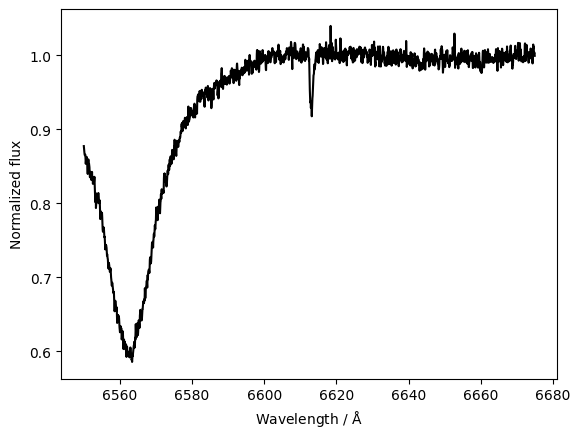

In [68]:
# plot spectrum
plt.plot(wav, spectra_array[4158 - 1], 'k-')
plt.xlabel(r'Wavelength / $\mathrm{\AA}$')
plt.ylabel(r'Normalized flux')
plt.show()

In [ ]:
u = X.mean(axis=0) # Povprečja stolpcev
B = X - u # Centriranje
C = 1 / (n-1) * B.T @ B
eigvals, eigvecs = np.linalg.eigh(C) # Lastni razcep

# sortiramo po padajoči vrednosti (večja varianca prva)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx] # (p,) padajoče
V = eigvecs[:, idx] # (p, p) stolpci = lastni vektorji

In [37]:
# kumulativna energija in delež
cum_energy = np.cumsum(eigvals) # g_j
total_energy = cum_energy[-1] # G
frac = cum_energy / total_energy # frakcija razložene variance do j-te komponente

# najdi najmanjše q za dano mejo eta (npr. 0.90)
eta = 0.90
q = int(np.searchsorted(frac, eta) + 1) # +1, ker indeksi začnejo pri 0, j pa pri 1

print(f"Za {eta*100:.1f}% energije potrebujemo q = {q} komponent.")

Za 90.0% energije potrebujemo q = 101 komponent.


In [69]:
print(frac)

[0.40312059 0.64350988 0.73068483 ... 0.99999869 0.99999935 1.        ]


In [45]:
W = V[:, :q]
T = X @ W

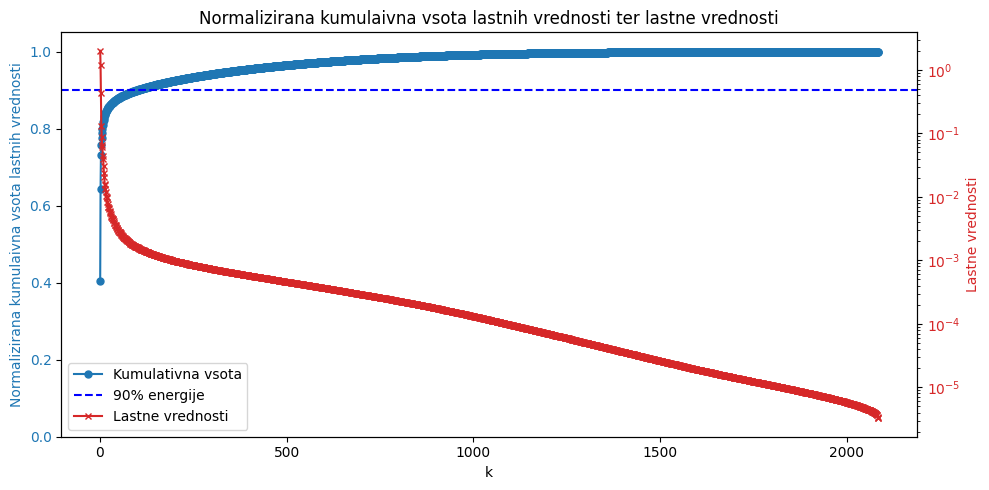

In [75]:
# predpostavka: frac in eigvals_sorted sta že definirana
x = np.arange(1, len(frac)+1)  # indeksi komponent (1..p)

fig, ax1 = plt.subplots(figsize=(10,5))

# leva y-os: kumulativna frakcija
color1 = 'tab:blue'
ax1.set_xlabel('k')
ax1.set_ylabel('Normalizirana kumulaivna vsota lastnih vrednosti', color=color1)
ax1.plot(x, frac, marker='o', markersize=5, color=color1, label='Kumulativna vsota')
ax1.axhline(0.90, color='blue', linestyle='--', label='90% energije')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0,1.05)

# desna y-os: lastne vrednosti
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Lastne vrednosti', color=color2)
ax2.plot(x, eigvals, marker='x', markersize=5, color=color2, label='Lastne vrednosti')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yscale('log')

# skupna legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title('Normalizirana kumulaivna vsota lastnih vrednosti ter lastne vrednosti')
plt.tight_layout()
plt.show()

[[ 10.8793036  -15.91088403  27.84767276   9.07733494]
 [ 10.41008389 -15.91035245  27.42562227   8.89064282]
 [  8.82917712 -16.14162842  28.03650749   8.89654432]
 ...
 [ 10.98615238 -15.97894144  27.36722438   9.04554229]
 [ 11.06771499 -15.73482127  27.23291106   9.11561296]
 [ 10.60210919 -15.82044204  27.75284143   9.06327978]]


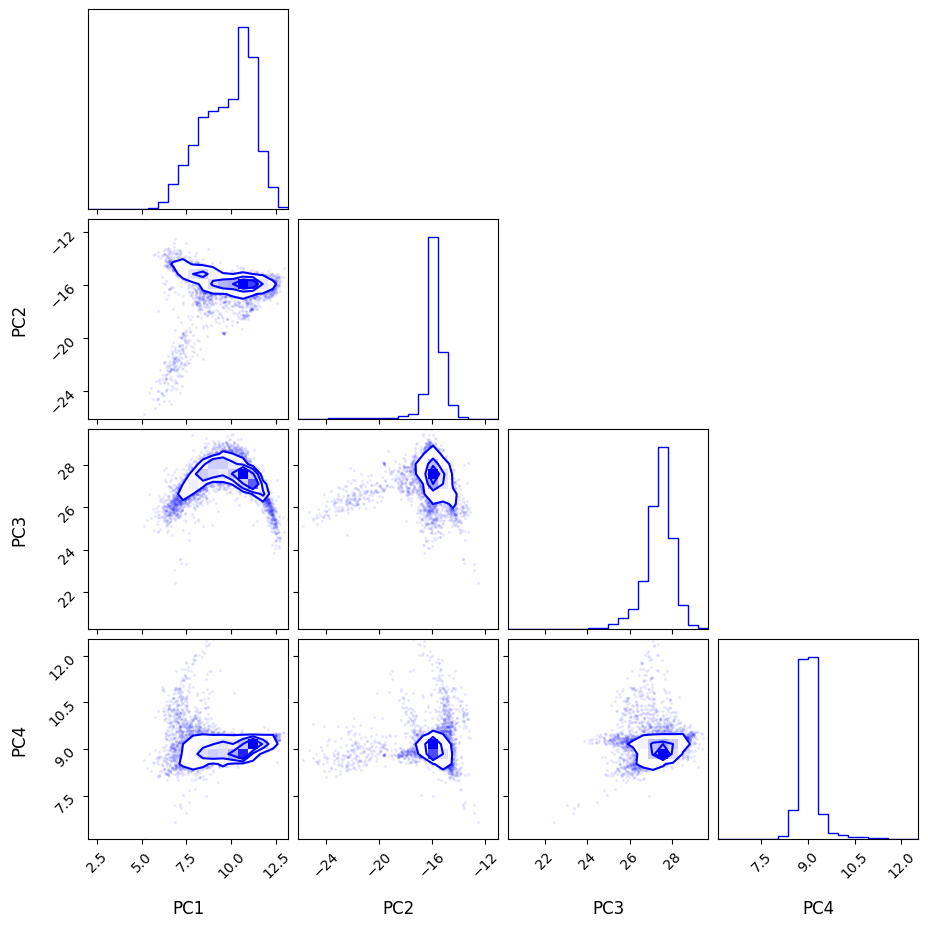

In [ ]:
# omejimo število komponent za preglednost (npr. prvih 4 ali 5)
q_plot = min(4, T.shape[1])
T_plot = T[:, :q_plot]
print(T_plot)

figure = corner.corner(
    T_plot,
    labels=[f"PC{i+1}" for i in range(q_plot)],
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 12},
    plot_datapoints=True,
    plot_density=True,       # riše tudi gostoto
    color='blue',
    bins=30
)

plt.show()

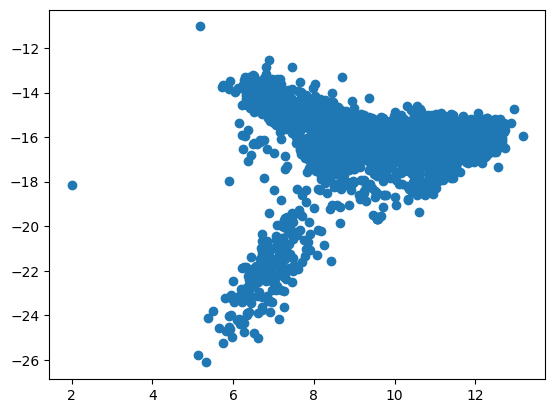

In [60]:
# omejimo število komponent za preglednost (npr. prvih 4 ali 5)
q_plot = min(4, T.shape[1])
T_plot = T[:, :q_plot]

plt.scatter(T_plot[:, 0], T_plot[:, 1])

In [ ]:
from sklearn.manifold import TSNE

# predpostavka: T = B @ W  # projekcija PCA (n_samples x q)
X_input = X  # lahko uporabimo tudi originalne podatke, npr. X

# opcijsko: standardizacija
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_input)

In [80]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    method='barnes_hut',
    metric='euclidean'
)
X_embedded = tsne.fit_transform(X_scaled)


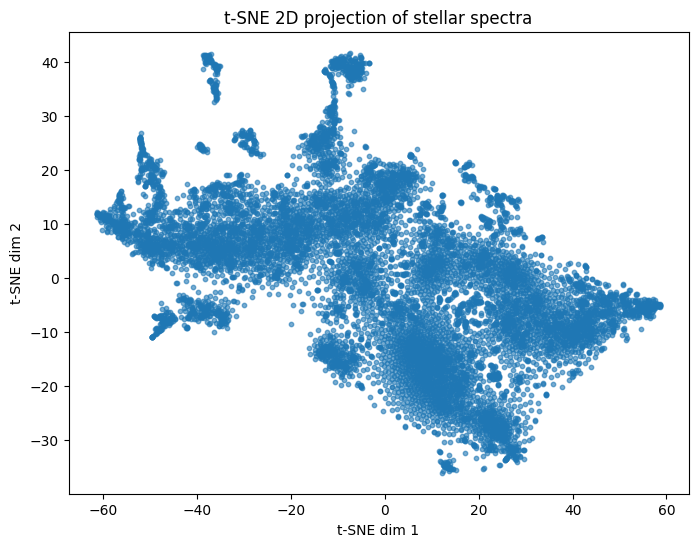

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(X_embedded[:,0], X_embedded[:,1], s=10, alpha=0.6)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('t-SNE 2D projection of stellar spectra')
plt.grid(False)
plt.show()
